In [87]:
import sys
sys.path.insert(0, '/Users/alam/code/rmps/')

from rmps_purity import *
from scipy.stats import linregress
import matplotlib.pyplot as plt
import scienceplots
from tqdm.notebook import tqdm

np.set_printoptions(precision=3, threshold=np.inf, suppress=True)

In [2]:
def process_data(data, n_list, k_copies, batch_size=1000, ti=False): 
    num_samples = data.shape[1]
    num_batches = int(num_samples//batch_size)
    
    h_purity = [haar_purity(n, k_copies, scaled=True, ti=ti) for n in n_list]
    
    err_mean = []
    err_std = []
    actual_n_list = []
    for i in range(len(data)):
        batches = [data[i,j*batch_size:(j+1)*batch_size] for j in range(num_batches)]
        purities = [samples_to_purity(batch, k_copies) for batch in batches]
        diff = np.array([p-h_purity[i] for p in purities])
        if np.all(diff > 0.0):
            one_err = np.sqrt(diff)
            err_mean.append(np.mean(one_err))
            err_std.append(np.std(one_err))
            actual_n_list.append(n_list[i])
    return err_mean, err_std, np.array(actual_n_list)

def set_style():
    plt.style.use(['science', 'grid', 'no-latex'])
    plt.rcParams['image.cmap'] = 'cividis'
    
    plt.rcParams['axes.labelsize'] = 8   
    plt.rcParams['xtick.labelsize'] = 8  
    plt.rcParams['ytick.labelsize'] = 8 
    plt.rcParams['legend.fontsize'] = 8 
    plt.rcParams['lines.linewidth'] = 1.5
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['figure.dpi'] = 300 
    
    plt.rcParams['axes.titlesize'] = 10
    
    plt.rcParams['axes.grid'] = True  
    plt.rcParams['axes.spines.top'] = True 
    plt.rcParams['axes.spines.right'] = True

# Run Oct 12th

## Open $\chi = n$

In [71]:
with open("open_linear.pickle", "rb") as f: 
    data = pickle.load(f)

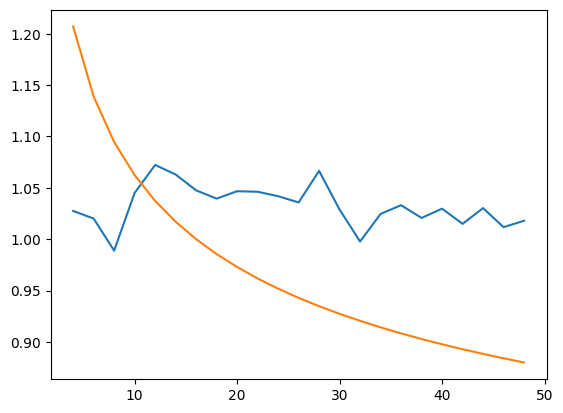

In [72]:
n_list = np.arange(4, 50+1, 2)
k_copies = 2
err_mean, _, n_list = process_data(data, n_list, k_copies, batch_size=50000)
plt.plot(n_list, err_mean)
plt.plot(n_list, 0.5+n_list**(-1/4))
#plt.ylim(0,2.5)

## Open $\chi\in [8,10,12,14,16,20,24,28,32]$ 

In [68]:
chi_list = [8,10,12,14,16,20,24,28,32]

data_array = []
for chi in chi_list:
    with open(f"open_{chi}.pickle", "rb") as f: 
        data_array.append(pickle.load(f))

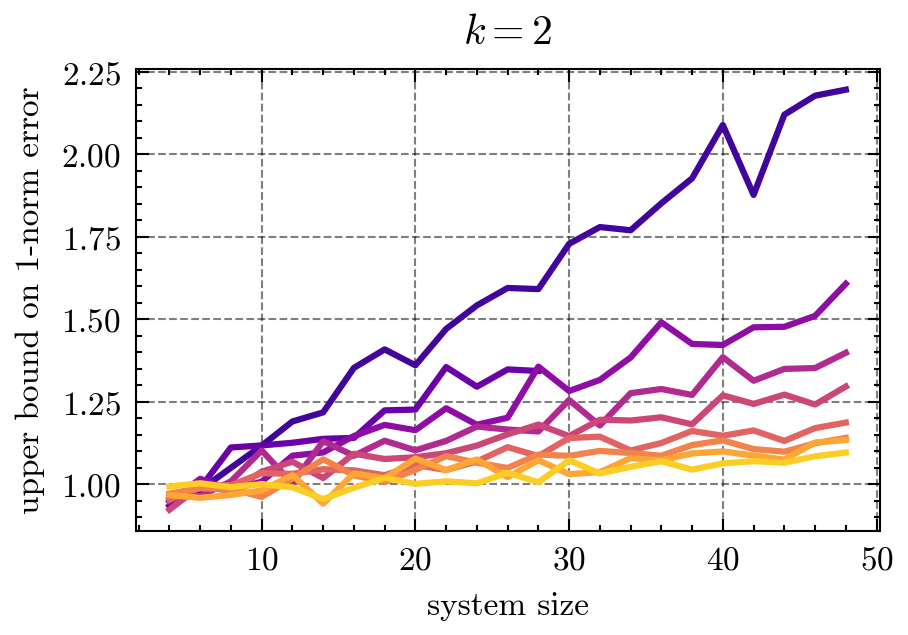

In [71]:
set_style()
fig, ax = plt.subplots(figsize=(3.2,2))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(chi_list)))

err_mean_array = []
n_array = []
k_copies = 2  

for chi,data in zip(chi_list, data_array): 
    n_list = [4+2*i for i in range(len(data))]
    err_mean, _, n_list = process_data(data, n_list, k_copies, batch_size=len(data[0]))
    err_mean_array.append(err_mean)
    n_array.append(n_list)
    
for chi, err_mean, n_list, color in zip(chi_list, err_mean_array, n_array, colors):
    plt.plot(n_list, err_mean, label=f'$\chi$ = {chi}', color=color)
#plt.legend()
plt.ylabel(r'upper bound on 1-norm error')
plt.xlabel('system size') 
plt.title(f"$k={k_copies}$")
plt.savefig("obc_plot1.pdf", format="pdf", bbox_inches="tight")

In [72]:
err_mean_array = []
n_array = []
k_copies = 2

for chi,data in zip(chi_list, data_array): 
    n_list = [4+2*i for i in range(len(data))]
    err_mean, _, n_list = process_data(data, n_list, k_copies, batch_size=len(data[0]))
    err_mean_array.append(err_mean)
    n_array.append(n_list)

slope_list2 = []
intercept_list2 = []
for err_mean, n_list in zip(err_mean_array, n_array):
    result = linregress(n_list, err_mean)
    slope_list2.append(result.slope)
    intercept_list2.append(result.intercept)
    print(f'1-r = {1-result.rvalue}')

1-r = 0.008399020073216357
1-r = 0.042750395985020395
1-r = 0.019821815831335465
1-r = 0.036438458477271896
1-r = 0.029028806931109652
1-r = 0.04583324561412949
1-r = 0.0854904297829806
1-r = 0.12298901396298911
1-r = 0.11633863255997756


In [73]:
err_mean_array = []
n_array = []
k_copies = 3

for chi,data in zip(chi_list, data_array): 
    n_list = [4+2*i for i in range(len(data))]
    err_mean, _, n_list = process_data(data, n_list, k_copies, batch_size=len(data[0]))
    err_mean_array.append(err_mean)
    n_array.append(n_list)
    
slope_list3 = []
intercept_list3 = []
for err_mean, n_list in zip(err_mean_array, n_array):
    result = linregress(n_list, err_mean)
    slope_list3.append(result.slope)
    intercept_list3.append(result.intercept)
    print(f'1-r = {1-result.rvalue}')

1-r = 0.026362820297584744
1-r = 0.049447258302113495
1-r = 0.019219563716701082
1-r = 0.07429185101083946
1-r = 0.041602688017465805
1-r = 0.05782493663123367
1-r = 0.07908311408714241
1-r = 0.12794767386227734
1-r = 0.13626041415724055


In [74]:
err_mean_array = []
n_array = []
k_copies = 4

for chi,data in zip(chi_list, data_array): 
    n_list = [4+2*i for i in range(len(data))]
    err_mean, _, n_list = process_data(data, n_list, k_copies, batch_size=len(data[0]))
    err_mean_array.append(err_mean)
    n_array.append(n_list)
    
slope_list4 = []
intercept_list4 = []
for err_mean, n_list in zip(err_mean_array, n_array):
    result = linregress(n_list, err_mean)
    slope_list4.append(result.slope)
    intercept_list4.append(result.intercept)
    print(f'1-r = {1-result.rvalue}')

1-r = 0.10890085560940033
1-r = 0.07002928506869877
1-r = 0.024989969003098245
1-r = 0.16747145680004916
1-r = 0.08915224935347033
1-r = 0.10578207482002178
1-r = 0.12908670601769012
1-r = 0.17530576078361992
1-r = 0.25492832201222493


In [75]:
err_mean_array = []
n_array = []
k_copies = 5

for chi,data in zip(chi_list, data_array): 
    n_list = [4+2*i for i in range(len(data))]
    err_mean, _, n_list = process_data(data, n_list, k_copies, batch_size=len(data[0]))
    err_mean_array.append(err_mean)
    n_array.append(n_list)
    
slope_list5 = []
intercept_list5 = []
for err_mean, n_list in zip(err_mean_array, n_array):
    result = linregress(n_list, err_mean)
    slope_list5.append(result.slope)
    intercept_list5.append(result.intercept)
    print(f'1-r = {1-result.rvalue}')

1-r = 0.24020911239129294
1-r = 0.10435924314492839
1-r = 0.03626184080895989
1-r = 0.283534318901161
1-r = 0.17593745111669845
1-r = 0.17254235153911335
1-r = 0.23094814327590452
1-r = 0.265237939632209
1-r = 0.4244560459285879


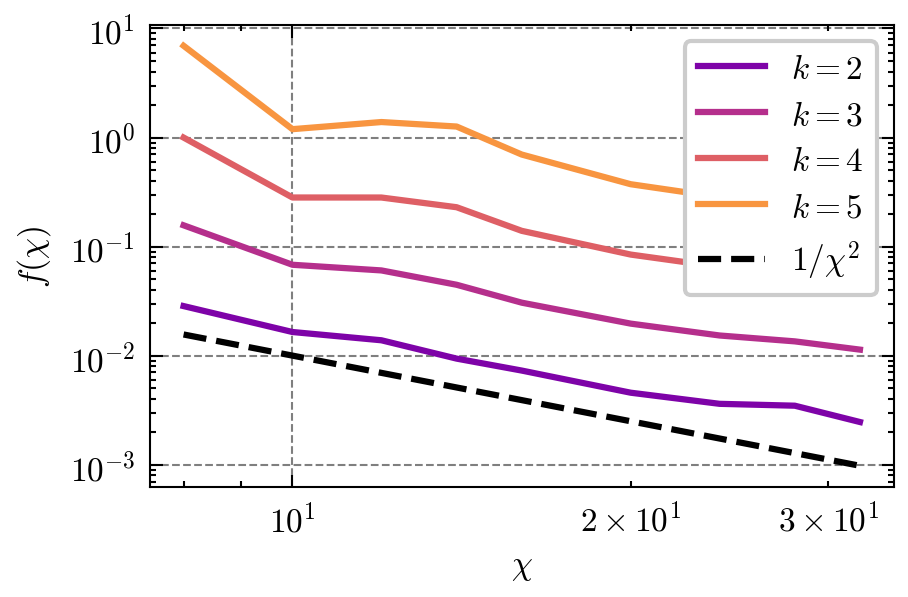

In [76]:
set_style()
fig, ax = plt.subplots(figsize=(3.2,2))
colors = plt.cm.plasma(np.linspace(0.25, 0.75, 4))

plt.plot(np.array(chi_list), slope_list2, label='$k=2$', color=colors[0])
plt.plot(np.array(chi_list), slope_list3, label='$k=3$', color=colors[1])
plt.plot(np.array(chi_list), slope_list4, label='$k=4$', color=colors[2])
plt.plot(np.array(chi_list), slope_list5, label='$k=5$', color=colors[3])
plt.plot(np.array(chi_list), 1/(np.array(chi_list)**2), '--', label=r"$1/\chi^2$", color='k')
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$f(\chi)$')
plt.xlabel(r'$\chi$')

plt.legend()
plt.savefig("obc_plot2.pdf", format="pdf", bbox_inches="tight")

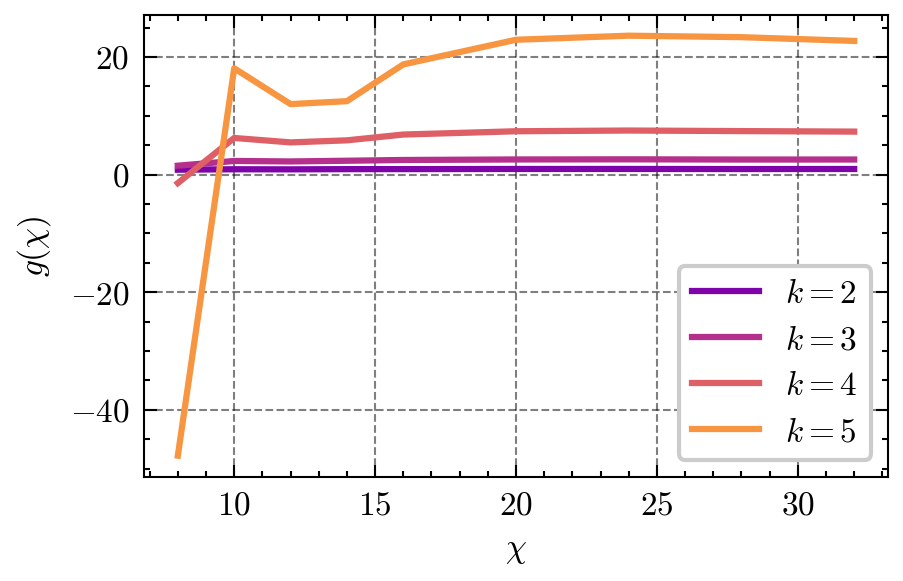

In [77]:
set_style()
fig, ax = plt.subplots(figsize=(3.2,2))
colors = plt.cm.plasma(np.linspace(0.25, 0.75, 4))

plt.plot(np.array(chi_list), intercept_list2, label='$k=2$', color=colors[0])
plt.plot(np.array(chi_list), intercept_list3, label='$k=3$', color=colors[1])
plt.plot(np.array(chi_list), intercept_list4, label='$k=4$', color=colors[2])
plt.plot(np.array(chi_list), intercept_list5, label='$k=5$', color=colors[3])
plt.ylabel(r'$g(\chi)$')
plt.xlabel(r'$\chi$')

plt.legend()
plt.savefig("obc_plot3.pdf", format="pdf", bbox_inches="tight")

In [78]:
intercept_list5

[-47.79507001412787,
 18.092638260348448,
 11.998938797199521,
 12.500129227975968,
 18.752618029893345,
 22.942776012939774,
 23.63520084088013,
 23.38365706353936,
 22.744933810927765]

# Run Oct 18th

## Periodic $\chi\in [4,8,10,12,14,16,20,24,28,32]$ 

In [79]:
#chi_list = [4,8,10,12,14,16,20,24,28,32]
chi_list = [4,8,10,12,16]
data_array = []
for chi in chi_list:
    with open(f"periodic_{chi}.pickle", "rb") as f: 
        data_array.append(pickle.load(f))
        
k_copies = 2

In [80]:
err_mean_array = []
n_array = []
for chi,data in zip(chi_list, data_array): 
    n_list = [4+2*i for i in range(len(data))]
    err_mean, _, n_list = process_data(data, n_list, k_copies, batch_size=len(data[0]))
    err_mean_array.append(err_mean)
    n_array.append(n_list)

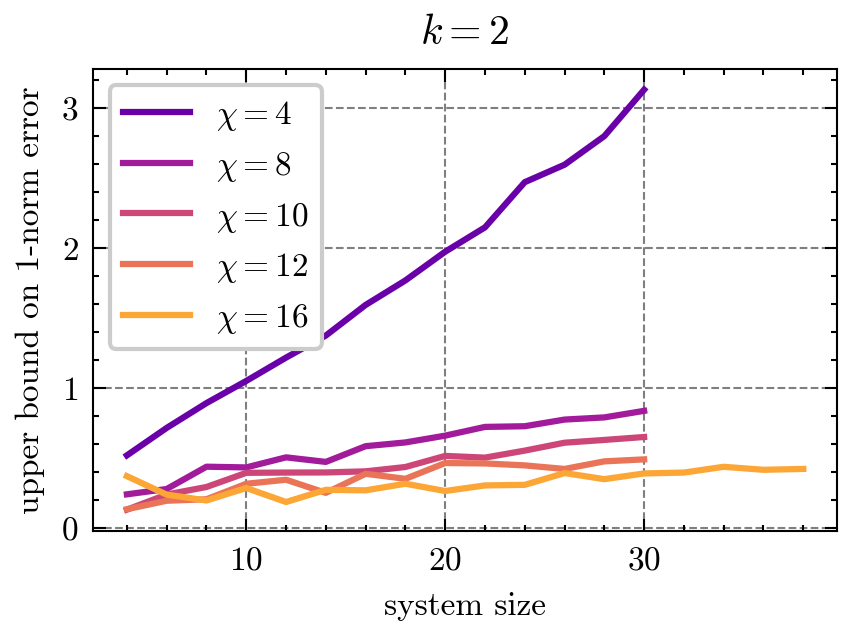

In [81]:
set_style()
fig, ax = plt.subplots(figsize=(3.2,2))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(chi_list)))

for chi, err_mean, n_list, color in zip(chi_list, err_mean_array, n_array, colors):
    plt.plot(n_list, err_mean, label=f'$\chi = {chi}$', color=color)
    
plt.ylabel(r'upper bound on 1-norm error')
plt.xlabel('system size') 
plt.title(f"$k={k_copies}$")
plt.savefig("pbc_plot1.pdf", format="pdf", bbox_inches="tight")
plt.legend()

In [82]:
#chi_list.insert(0, 4)
#slope_list = [0.09221627538012181, ]
slope_list = []
for err_mean, n_list in zip(err_mean_array, n_array):
    result = linregress(n_list, err_mean)
    slope_list.append(result.slope)
    print(f'1-r = {1-result.rvalue}')

1-r = 0.0026599784908564184
1-r = 0.0177720207148806
1-r = 0.02946745071137269
1-r = 0.07812786964137852
1-r = 0.22576630026877897


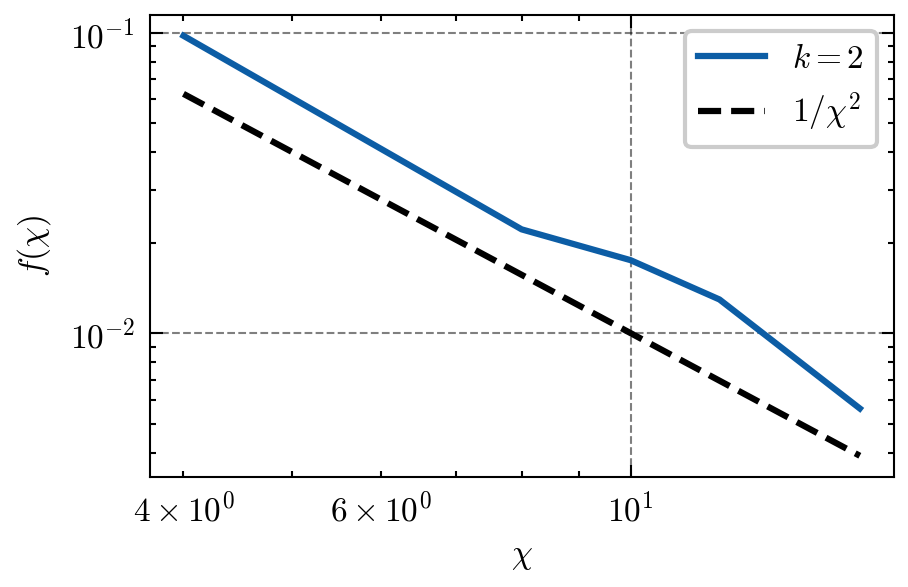

In [83]:
set_style()
fig, ax = plt.subplots(figsize=(3.2,2))
colors = plt.cm.plasma(np.linspace(0.25, 0.75, 4))

plt.plot(chi_list, slope_list, label="$k=2$") 
plt.plot(np.array(chi_list), 1/(np.array(chi_list)**2), '--', label=r"$1/\chi^2$", color='k')
plt.ylabel(r'$f(\chi)$')
plt.xlabel(r'$\chi$')
plt.yscale('log')
plt.xscale('log')

plt.legend()
plt.savefig("pbc_plot2.pdf", format="pdf", bbox_inches="tight")

## TI $\chi\in [8,10,12,14,16,20,24,28,32]$ 

In [84]:
chi_list = [8,10,12,14,16,20,24,28]

data_array = []
for chi in chi_list:
    with open(f"ti_{chi}.pickle", "rb") as f: 
        data_array.append(pickle.load(f))
        
k_copies = 2 

In [85]:
err_mean_array = []
n_array = []
for chi,data in zip(chi_list, data_array): 
    n_list = [4+2*i for i in range(len(data))]
    err_mean, _, n_list = process_data(data, n_list, k_copies, batch_size=len(data[0]), ti=True)
    err_mean_array.append(err_mean)
    n_array.append(n_list)

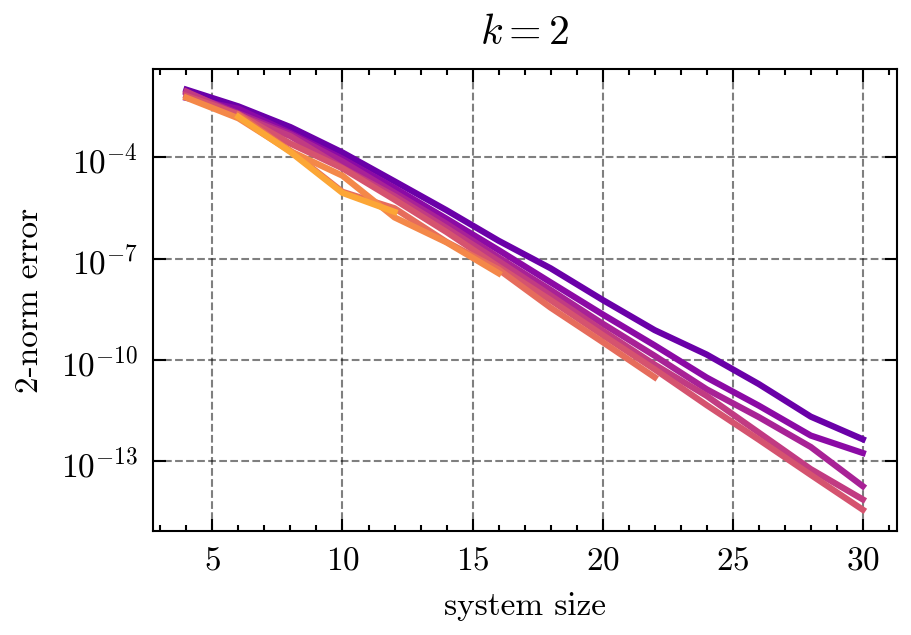

In [90]:
set_style()
fig, ax = plt.subplots(figsize=(3.2,2))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(chi_list)))

for chi, err_mean, n_list, color in zip(chi_list, err_mean_array, n_array, colors):
    h_purities = [haar_purity(n, k_copies, ti=True) for n in n_list]
    two_norm_errs = [err*h for (err,h) in zip(err_mean,h_purities)]
    plt.plot(n_list, two_norm_errs, label=f'$\chi = {chi}$', color=color)
    
plt.ylabel(r'2-norm error')
plt.xlabel('system size') 
plt.title(f"$k={k_copies}$")
plt.yscale('log')
plt.savefig("ti_plot1.pdf", format="pdf", bbox_inches="tight")

#plt.legend()